# Reading in Data

In [1]:
import pandas as pd

In [2]:
customers = pd .read_csv("In-Game purchases.csv")
customers.head()

,Email,Address,Avatar,Avg. Session Length,Time on App,Time on Website,Length of Membership,Yearly Amount Spent
0,mstephenson@fernandez.com,"835 Frank Tunnel\nWrightmouth, MI 82180-9605",Violet,34.497268,12.655651,39.577668,4.082621,587.951054
1,hduke@hotmail.com,"4547 Archer Common\nDiazchester, CA 06566-8576",DarkGreen,31.926272,11.109461,37.268959,2.664034,392.204933
2,pallen@yahoo.com,"24645 Valerie Unions Suite 582\nCobbborough, D...",Bisque,33.000915,11.330278,37.110597,4.104543,487.547505
3,riverarebecca@gmail.com,"1414 David Throughway\nPort Jason, OH 22070-1220",SaddleBrown,34.305557,13.717514,36.721283,3.120179,581.852344
4,mstephens@davidson-herman.com,"14023 Rodriguez Passage\nPort Jacobville, PR 3...",MediumAquaMarine,33.330673,12.795189,37.536653,4.446308,599.406092


# Setting up Variables

In [3]:
from sklearn.model_selection import train_test_split

train, test = train_test_split(
    customers,
    random_state = 15
)

In [4]:
# Set up the dependent variable as Yearly Amount Spent >= 500
dependent = train['Yearly Amount Spent'] >= 500

In [5]:
# Set up the independent variables as the columns:
#   Avg. Session Length
#   Time on App
#   Time on Website
#   Length of Membership
independent = train[[
    'Avg. Session Length',
    'Time on App',
    'Time on Website',
    'Length of Membership'
]]

In [6]:
import statsmodels.api as sm
independent = sm.add_constant(independent)

# Building a Logistic Regression moodel

In [7]:
model = sm.Logit(
    dependent,
    independent
).fit()

model.summary()

Optimization terminated successfully.
         Current function value: 0.079909
         Iterations 12


<class 'statsmodels.iolib.summary.Summary'>
"""
                            Logit Regression Results                           
===============================================================================
Dep. Variable:     Yearly Amount Spent   No. Observations:                  375
Model:                           Logit   Df Residuals:                      370
Method:                            MLE   Df Model:                            4
Date:                 Wed, 24 Sep 2025   Pseudo R-squ.:                  0.8847
Time:                         16:44:51   Log-Likelihood:                -29.966
converged:                        True   LL-Null:                       -259.90
Covariance Type:             nonrobust   LLR p-value:                 3.205e-98
========================================================================================
                           coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                 -379.1524     77.678     -4.881      0.000    -531.398    -226.907
Avg. Session Length      6.4501      1.339      4.816      0.000       3.825       9.075
Time on App              8.4300      1.719      4.905      0.000       5.061      11.799
Time on Website          0.3154      0.370      0.853      0.394      -0.409       1.040
Length of Membership    14.8151      2.990      4.956      0.000       8.956      20.674
========================================================================================

Possibly complete quasi-separation: A fraction 0.62 of observations can be
perfectly predicted. This might indicate that there is complete
quasi-separation. In this case some parameters will not be identified.
"""

# Evaluating the logistic regression model

In [10]:
test_dependent = test['Yearly Amount Spent'] >= 500

test_independent = test[['Avg. Session Length',
                         'Time on App',
                         'Time on Website',
                         'Length of Membership']]

# we need to add the constant here too
test_independent = sm.add_constant(test_independent)

predicted = model.predict(test_independent) > 0.5

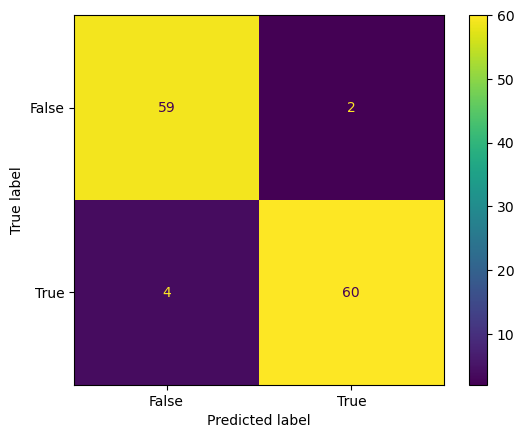

In [13]:
# Import necessary libraries
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Assuming test_dependent and predicted are pre-defined lists or arrays
# Calculate the confusion matrix
cm = confusion_matrix(test_dependent, predicted, labels=list(set(test_dependent))) #Use set to get unique labels.

# Create a ConfusionMatrixDisplay object
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=list(set(test_dependent))) #Use set to get unique labels.
# Plot the confusion matrix
disp.plot()
# Show the plot
plt.show()

In [14]:
from sklearn.metrics import classification_report
print(classification_report(test_dependent, predicted))

              precision    recall  f1-score   support

       False       0.94      0.97      0.95        61
        True       0.97      0.94      0.95        64

    accuracy                           0.95       125
   macro avg       0.95      0.95      0.95       125
weighted avg       0.95      0.95      0.95       125



In [15]:
model.predict(test_independent)

369    9.998859e-01
55     2.195928e-01
270    9.999603e-01
387    9.754985e-05
200    1.801827e-02
           ...     
115    2.402233e-09
322    1.016776e-01
228    8.152118e-06
135    5.749388e-03
120    9.999939e-01
Length: 125, dtype: float64